In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

## Load Data

In [2]:
rat_names = ['achilles', 'gatsby','cicero', 'buddy']
rat_name = rat_names[1]
data = np.load(f'../datasets/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']

## BunDLe-Net

In [3]:
x_, b_ = prep_data(x, b, win=20)

### Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=b_.shape[1])
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='continuous',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=300,
    initialisation='pca_init'
)

Loss [Markov, Behaviour, Total]: [0.0042 0.0008 0.005 ]: 100%|█| 300/300 [01:58<


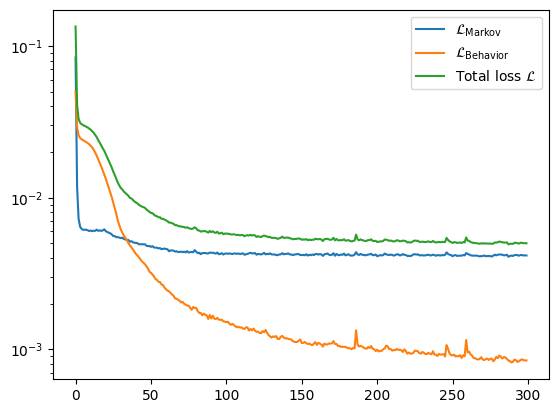

In [4]:
plt.figure()
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

In [5]:
y0_ = model.tau(x_[:,0]).numpy() 

## Visualising embedding

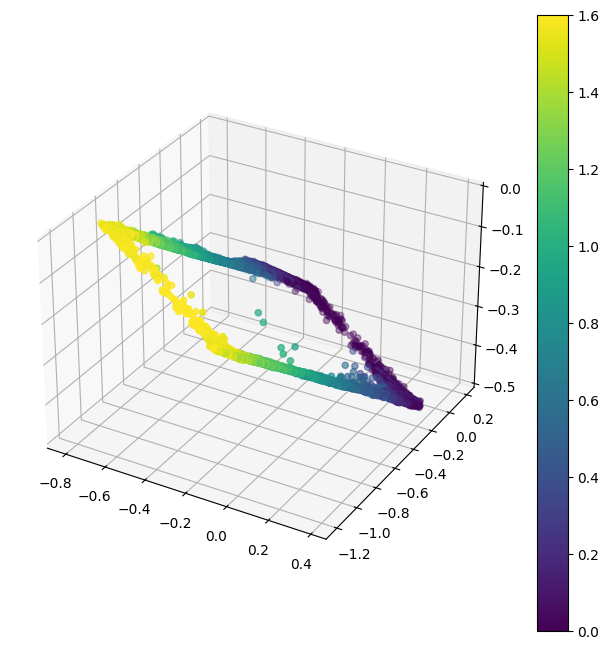

In [6]:
#%matplotlib notebook
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
true_y_line = ax.scatter(y0_[:, 0], y0_[:, 1], y0_[:, 2], c=b_[:,0])
plt.colorbar(true_y_line)
plt.show()

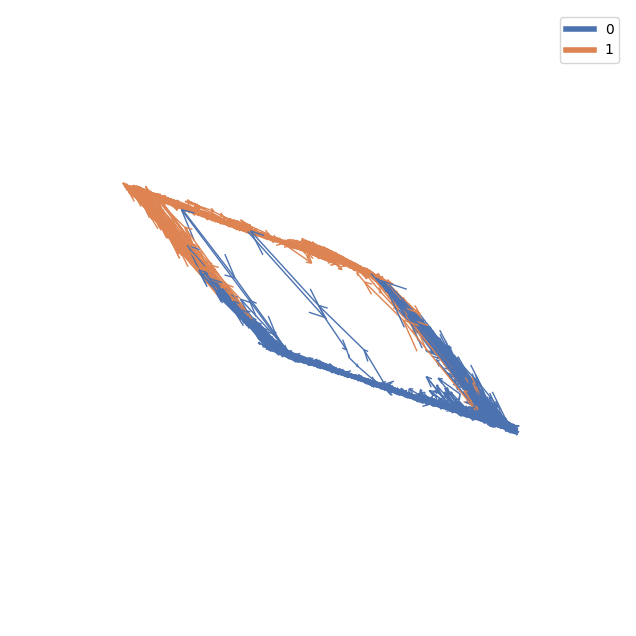

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [12]:
vis = LatentSpaceVisualiser(y0_, b_[:, 1].astype(int), b_names=['0', '1'])
vis.plot_phase_space(arrow_length_ratio=0.2)